<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-depression-data-ml-83-64?scriptVersionId=228055039" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-depression-dataset/student_depression_dataset.csv


## Title: Student Depression Dataset

#### Description: This dataset contains information on students' mental health, focusing on depression levels, lifestyle factors, academic performance, and social influences. It includes features such as age, gender, sleep patterns, study hours, social interactions, stress levels, and self-reported depression scores. The dataset can be used for analyzing mental health trends, identifying risk factors, and developing predictive models for student well-being.







## import dataset

In [2]:
df = pd.read_csv('/kaggle/input/student-depression-dataset/student_depression_dataset.csv')

In [3]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [7]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object

In [10]:
df.shape

(27901, 18)

In [11]:
df.corr

<bound method DataFrame.corr of            id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Sat

In [12]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

# Data visulizations

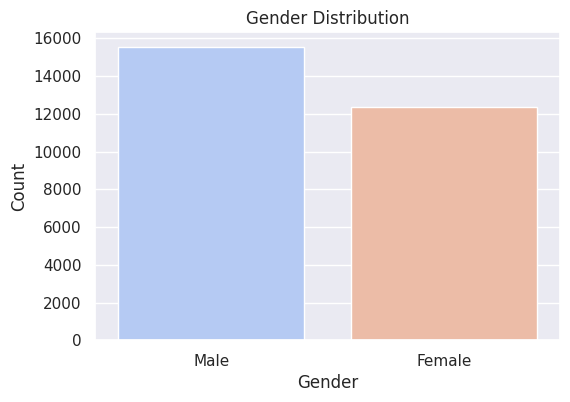

In [13]:
# Set style
sns.set_theme(style="darkgrid")

# Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='coolwarm')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

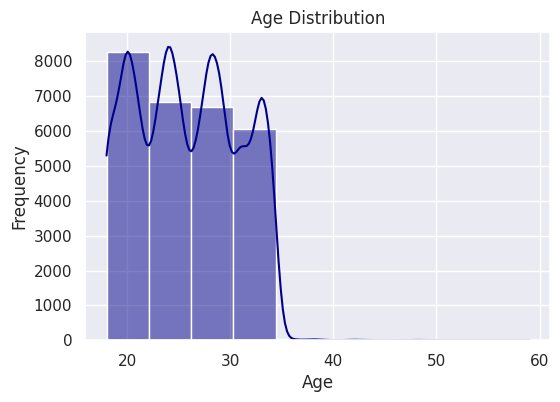

In [14]:
# Age Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=10, kde=True, color='darkblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

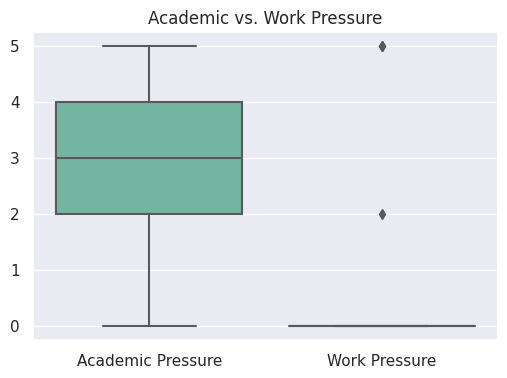

In [15]:
# Academic vs. Work Pressure (Box Plot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[['Academic Pressure', 'Work Pressure']], palette='Set2')
plt.title("Academic vs. Work Pressure")
plt.show()

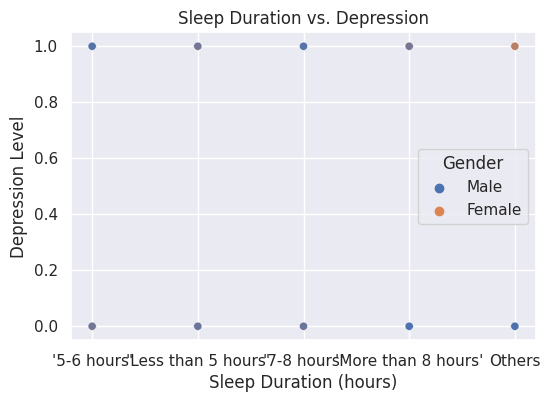

In [16]:
# Sleep Duration vs. Depression (Scatter Plot)
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Sleep Duration', y='Depression', hue='Gender', data=df, alpha=0.7)
plt.title("Sleep Duration vs. Depression")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Depression Level")
plt.show()

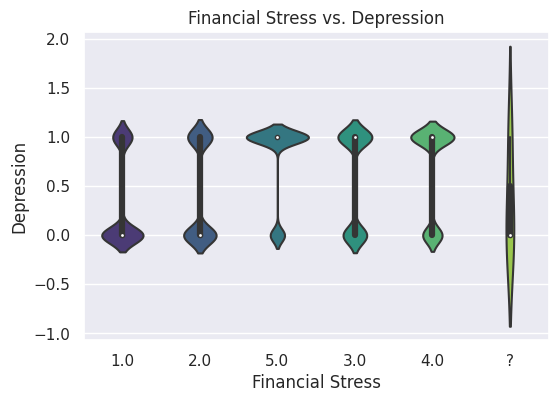

In [17]:
# Financial Stress vs. Depression (Violin Plot)
plt.figure(figsize=(6, 4))
sns.violinplot(x='Financial Stress', y='Depression', data=df, palette='viridis')
plt.title("Financial Stress vs. Depression")
plt.show()

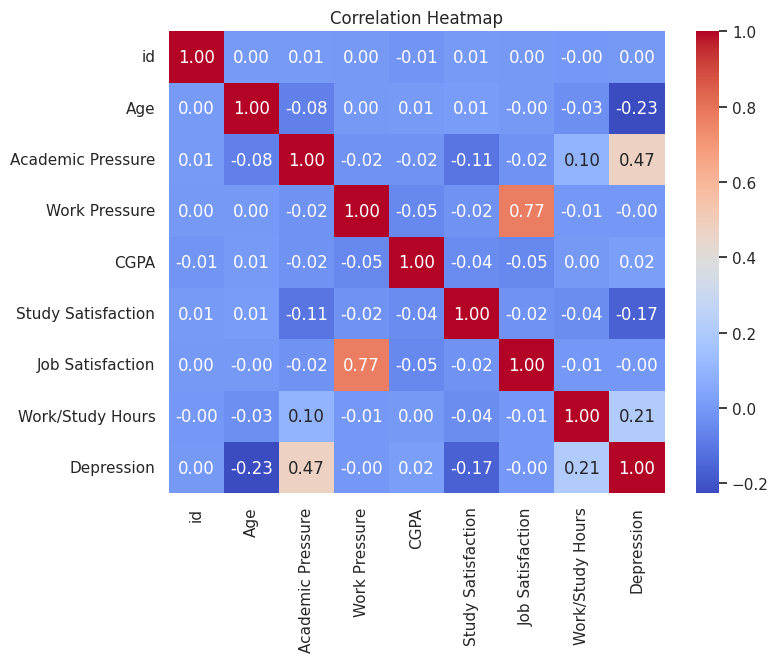

In [18]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [20]:
# Drop 'id' column if it exists
df.drop(columns=['id'], inplace=True, errors='ignore')

In [21]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [22]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = ['Gender', 'City', 'Profession', 'Degree', 'Dietary Habits', 
                    'Sleep Duration', 'Have you ever had suicidal thoughts ?', 
                    'Family History of Mental Illness']

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip("'")  # Remove extra quotes
    df[col] = le.fit_transform(df[col])

# Check if all values are numeric
print(df.dtypes)


Gender                                     int64
Age                                      float64
City                                       int64
Profession                                 int64
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                             int64
Dietary Habits                             int64
Degree                                     int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness           int64
Depression                                 int64
dtype: object


In [23]:
# Handling missing values (filling with median for numerical columns)
df.fillna(df.median(numeric_only=True), inplace=True)

In [24]:
# Define features and target
X = df.drop(columns=['Depression'])
y = df['Depression']

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [27]:
import numpy as np
X_train.replace('?', np.nan, inplace=True)
X_test.replace('?', np.nan, inplace=True)

In [28]:
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Family History of Mental Illness'],
      dtype='object')
Categorical Columns: Index(['Financial Stress'], dtype='object')


In [29]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Impute categorical columns with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [30]:
# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100  
    accuracy_results[name] = accuracy

In [31]:
# Display accuracy results
for model, acc in accuracy_results.items():
    print(f"{model}: {acc:.2f}%")

Logistic Regression: 83.64%
Random Forest: 82.60%
SVM: 83.43%
KNN: 74.65%
Gradient Boosting: 83.73%


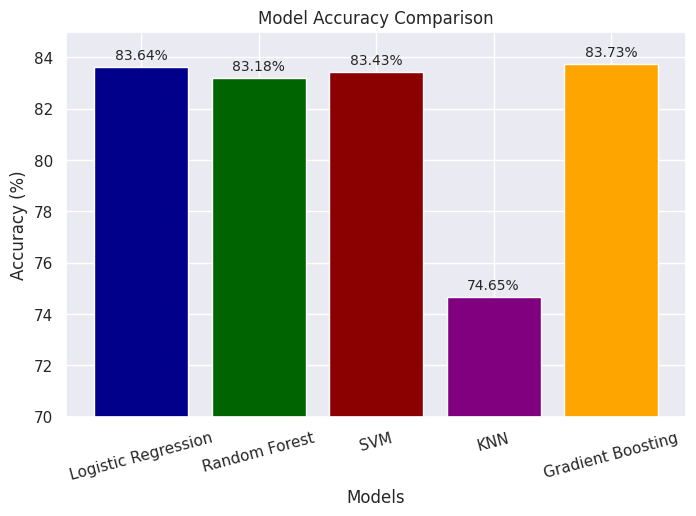

In [32]:
import matplotlib.pyplot as plt

# Model names and their corresponding accuracy scores
models = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN', 'Gradient Boosting']
accuracy = [83.64, 83.18, 83.43, 74.65, 83.73]

# Creating the bar plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color=['darkblue', 'darkgreen', 'darkred', 'purple', 'orange'])

# Adding labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(70, 85)  # Setting y-axis limits for better visibility

# Display values on top of bars
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center', fontsize=10)

# Show the plot
plt.xticks(rotation=15)  # Rotate x-axis labels for readability
plt.show()


## Thank you!!!!!!...upvote pls!!!